---
format:
    html: default
    ipynb: default
jupyter: python3
---


## Explaining CNNs


In this assignment you implement two explainer algorithms for Convolutional Neural Networks (CNNs) and use them to inspect a model you have already trained. An explainer answers a question that accuracy alone cannot: which parts of an input drove this particular prediction? For an image classifier that answer takes the form of a saliency map, and a trustworthy map should highlight the animal rather than the background, a watermark, or some dataset artifact the model latched onto.

We invite you to watch the following video, which sets the context and walks through the tools you can use. Click the thumbnail to open it on YouTube.

[![Watch the assignment introduction on YouTube](https://img.youtube.com/vi/Am2EF9CLu-g/hqdefault.jpg)](https://www.youtube.com/watch?v=Am2EF9CLu-g)

In the [cats vs dogs](https://huggingface.co/datasets/pantelism/cats-vs-dogs) [classification task](https://aegean.ai/aiml-common/lectures/cnn/cnn-example-architectures/using_convnets_with_small_datasets) you trained a model that, with the help of data augmentation, reached a useful level of accuracy without overfitting. That trained model is your subject here. You do not retrain it or change its architecture; you attach explainers to it and interpret what they reveal about how it decides.

### The two methods you will implement

**Integrated gradients** ([Sundararajan et al., 2017](https://arxiv.org/abs/1703.01365)) attributes a prediction to individual input pixels. It picks a baseline image (commonly an all-black image, which the model should find uninformative) and integrates the gradient of the class score along the straight-line path from that baseline to the actual input. The result is a per-pixel attribution with two properties that plain input gradients lack: completeness, meaning the attributions sum to the difference in model output between the input and the baseline, and robustness to saturated activations, where a plain gradient would read close to zero even though the feature mattered.

**Grad-CAM** ([Selvaraju et al., 2016](https://arxiv.org/abs/1610.02391)) produces a coarse, class-discriminative heatmap. It takes the feature maps of a convolutional layer, usually the last one, and weights each map by the gradient of the class score flowing into it. Because it works at the resolution of a deep feature map rather than the raw pixels, it localizes the region the network used instead of scoring every pixel.

The two methods sit at opposite ends of a resolution trade-off: integrated gradients is fine-grained and pixel-level, Grad-CAM is coarse and region-level. Running both on the same image and noting where they agree, and where they do not, is the heart of this assignment.

We strongly advise PyTorch with [Captum](https://captum.ai/tutorials/) unless you already have Keras/TF expertise, because both methods ship as ready implementations there (`IntegratedGradients` and `LayerGradCam`). You are free to use the high-level APIs of the framework of your choice.

### What to submit

For each method, in the cells below:

- A markdown explanation written so that anyone who understands how a CNN works can follow it. Cover the intuition, the role of the baseline (integrated gradients) or the target layer (Grad-CAM), and one limitation of the method.
- Working code that runs the explainer on at least three correctly classified images and at least one image the model got wrong.
- The resulting maps overlaid on the input images, each with a one-line caption stating what the map suggests the model attended to.

### How your work is evaluated

- Correctness: the right baseline, the right target layer, and gradients taken with respect to the predicted class rather than a fixed label.
- Visualization quality: maps are overlaid on the inputs, readable, and labeled.
- Depth of interpretation: noting that a map "looks reasonable" is not enough. Point to where the two methods agree, where they disagree, and what the misclassified example tells you about what the model actually learned.

In [1]:
!pip install -q captum datasets

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset

from captum.attr import IntegratedGradients, LayerGradCam
from captum.attr import LayerAttribution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 29.3 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [4]:
class SmallConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


model = SmallConvNet().to(device)

state_dict = torch.load(
    "/content/cats_and_dogs_small.pth",
    map_location=device
)

model.load_state_dict(state_dict)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [5]:
dataset = load_dataset("pantelism/cats-vs-dogs")

print(dataset)
print(dataset["train"].features)

README.md:   0%|          | 0.00/602 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 45.7MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.3MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cat', 'dog'])}


In [8]:
test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

test_dataset = dataset["test"]

def prepare_example(example):
    image = example["image"].convert("RGB")
    image_tensor = test_transform(image)
    label = example["label"]
    return image_tensor, label

image, label = prepare_example(test_dataset[0])

print("Image shape:", image.shape)
print("Label:", label, "-", "cat" if label == 0 else "dog")
print("Pixel range:", image.min().item(), "to", image.max().item())

Image shape: torch.Size([3, 150, 150])
Label: 0 - cat
Pixel range: -1.0 to 0.9921568632125854


In [9]:
correct_examples = []
incorrect_examples = []

model.eval()

with torch.no_grad():
    for i in range(len(test_dataset)):
        image, true_label = prepare_example(test_dataset[i])

        x = image.unsqueeze(0).to(device)
        logit = model(x).squeeze()
        probability = torch.sigmoid(logit).item()

        # 0 = cat, 1 = dog
        predicted_label = 1 if probability >= 0.5 else 0

        result = {
            "index": i,
            "image": image,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "probability": probability
        }

        if predicted_label == true_label:
            correct_examples.append(result)
        else:
            incorrect_examples.append(result)


print("Correct:", len(correct_examples))
print("Incorrect:", len(incorrect_examples))
print("Test accuracy:", len(correct_examples) / len(test_dataset))

# Select the four images we'll explain
selected_examples = correct_examples[:3] + incorrect_examples[:1]

for example in selected_examples:
    true_name = "dog" if example["true_label"] == 1 else "cat"
    pred_name = "dog" if example["predicted_label"] == 1 else "cat"

    print(
        f'Index {example["index"]}: '
        f'True = {true_name}, '
        f'Predicted = {pred_name}, '
        f'Dog probability = {example["probability"]:.3f}'
    )

Correct: 644
Incorrect: 356
Test accuracy: 0.644
Index 0: True = cat, Predicted = cat, Dog probability = 0.137
Index 3: True = cat, Predicted = cat, Dog probability = 0.456
Index 4: True = cat, Predicted = cat, Dog probability = 0.173
Index 1: True = cat, Predicted = dog, Dog probability = 0.920


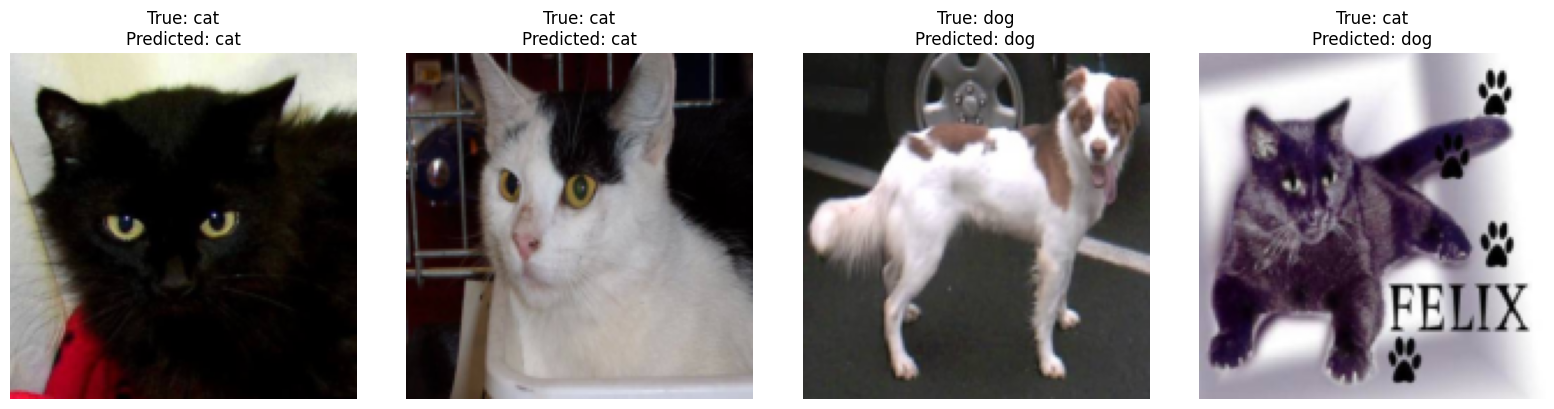

In [10]:
correct_cats = [e for e in correct_examples if e["true_label"] == 0]
correct_dogs = [e for e in correct_examples if e["true_label"] == 1]

# Use 2 correctly classified cats, 1 correctly classified dog,
# and 1 misclassified image
selected_examples = [
    correct_cats[0],
    correct_cats[1],
    correct_dogs[0],
    incorrect_examples[0]
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, example in zip(axes, selected_examples):
    # Undo normalization for display: [-1, 1] -> [0, 1]
    display_image = example["image"] * 0.5 + 0.5
    display_image = display_image.permute(1, 2, 0).numpy()

    true_name = "dog" if example["true_label"] == 1 else "cat"
    pred_name = "dog" if example["predicted_label"] == 1 else "cat"

    ax.imshow(display_image)
    ax.set_title(
        f'True: {true_name}\n'
        f'Predicted: {pred_name}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Integrated Gradients

Integrated Gradients explains a prediction by measuring how the model's output changes as the input moves from a baseline image to the actual image. Instead of using the gradient at only the final input, it averages gradients along many points between the baseline and the input. The resulting attribution values indicate which pixels contributed most strongly to the prediction.

I use an all-black image as the baseline. Because the model inputs are normalized from [0, 1] to [-1, 1], black pixels are represented by -1 after normalization. This baseline represents the absence of visible image content while remaining consistent with the model's preprocessing.

One limitation of Integrated Gradients is that the explanation depends on the choice of baseline. A different baseline can produce different attribution patterns, so the resulting map should not be interpreted as a unique explanation of the model's decision.

In [11]:
# Captum needs a scalar representing the class being explained.
# The network has one logit: positive evidence means dog and
# negative evidence means cat.
def predicted_class_score(x):
    logits = model(x)

    predicted_dog = (logits >= 0).float()

    # Explain the model's predicted class:
    # dog -> use the logit
    # cat -> use the negative logit
    return torch.where(
        predicted_dog.bool(),
        logits,
        -logits
    )


ig = IntegratedGradients(predicted_class_score)

print("Integrated Gradients ready.")

Integrated Gradients ready.


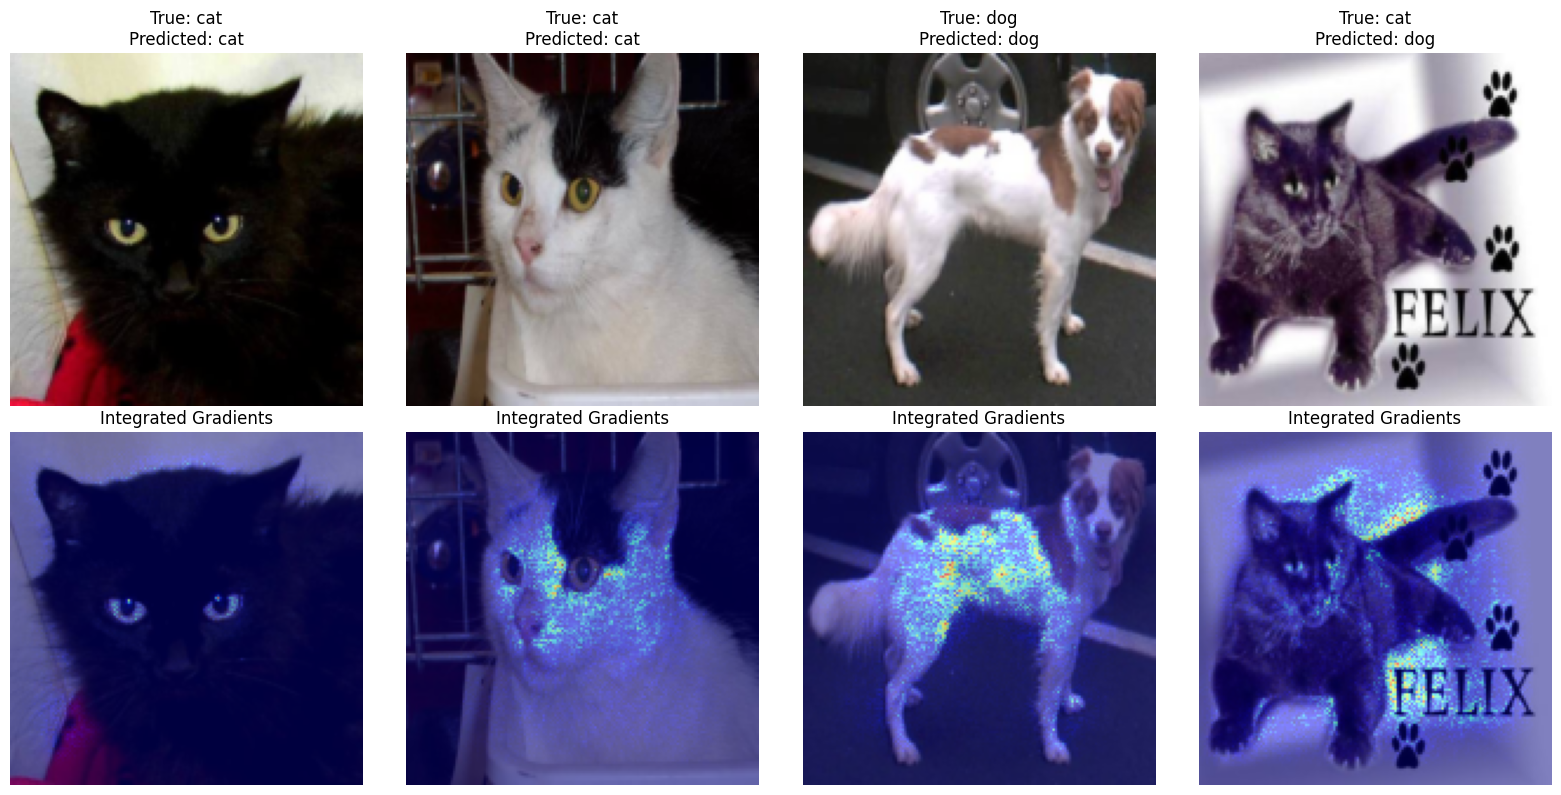

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, example in enumerate(selected_examples):
    image = example["image"].unsqueeze(0).to(device)

    # Black image in normalized input space
    baseline = torch.full_like(image, -1.0)

    # Calculate Integrated Gradients
    attributions = ig.attribute(
        image,
        baselines=baseline,
        n_steps=50
    )

    # Combine RGB-channel attribution magnitudes
    attribution_map = attributions.abs().sum(dim=1).squeeze()

    # Normalize attribution map for visualization
    attribution_map = attribution_map.detach().cpu().numpy()
    attribution_map = attribution_map / (attribution_map.max() + 1e-8)

    # Undo image normalization for display
    display_image = example["image"] * 0.5 + 0.5
    display_image = display_image.permute(1, 2, 0).numpy()

    true_name = "dog" if example["true_label"] == 1 else "cat"
    pred_name = "dog" if example["predicted_label"] == 1 else "cat"

    # Original
    axes[0, i].imshow(display_image)
    axes[0, i].set_title(
        f"True: {true_name}\nPredicted: {pred_name}"
    )
    axes[0, i].axis("off")

    # Integrated Gradients overlay
    axes[1, i].imshow(display_image)
    axes[1, i].imshow(
        attribution_map,
        cmap="jet",
        alpha=0.5
    )
    axes[1, i].set_title("Integrated Gradients")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### Integrated Gradients observations

1. **Correct cat 1:** The attribution is relatively sparse, with some emphasis around the cat's facial features and boundaries.
2. **Correct cat 2:** The strongest attributions are concentrated around the cat's face, particularly the eyes and central facial region.
3. **Correct dog:** Attribution is distributed across the dog's body, especially the torso, head, and body contours, suggesting that the model used features of the animal itself.
4. **Misclassified cat:** The model attributes substantial importance to the "FELIX" text and other graphic/background regions in addition to the cat. This suggests that unrelated visual features may have contributed to the incorrect dog prediction.

## Grad-CAM

Grad-CAM explains a CNN prediction by using the gradients flowing into a convolutional layer to determine which spatial regions were important to the prediction. I use the final convolutional layer because it contains the highest-level spatial features before classification.

One limitation is that Grad-CAM produces a coarse heatmap, so it cannot identify important individual pixels as precisely as Integrated Gradients.

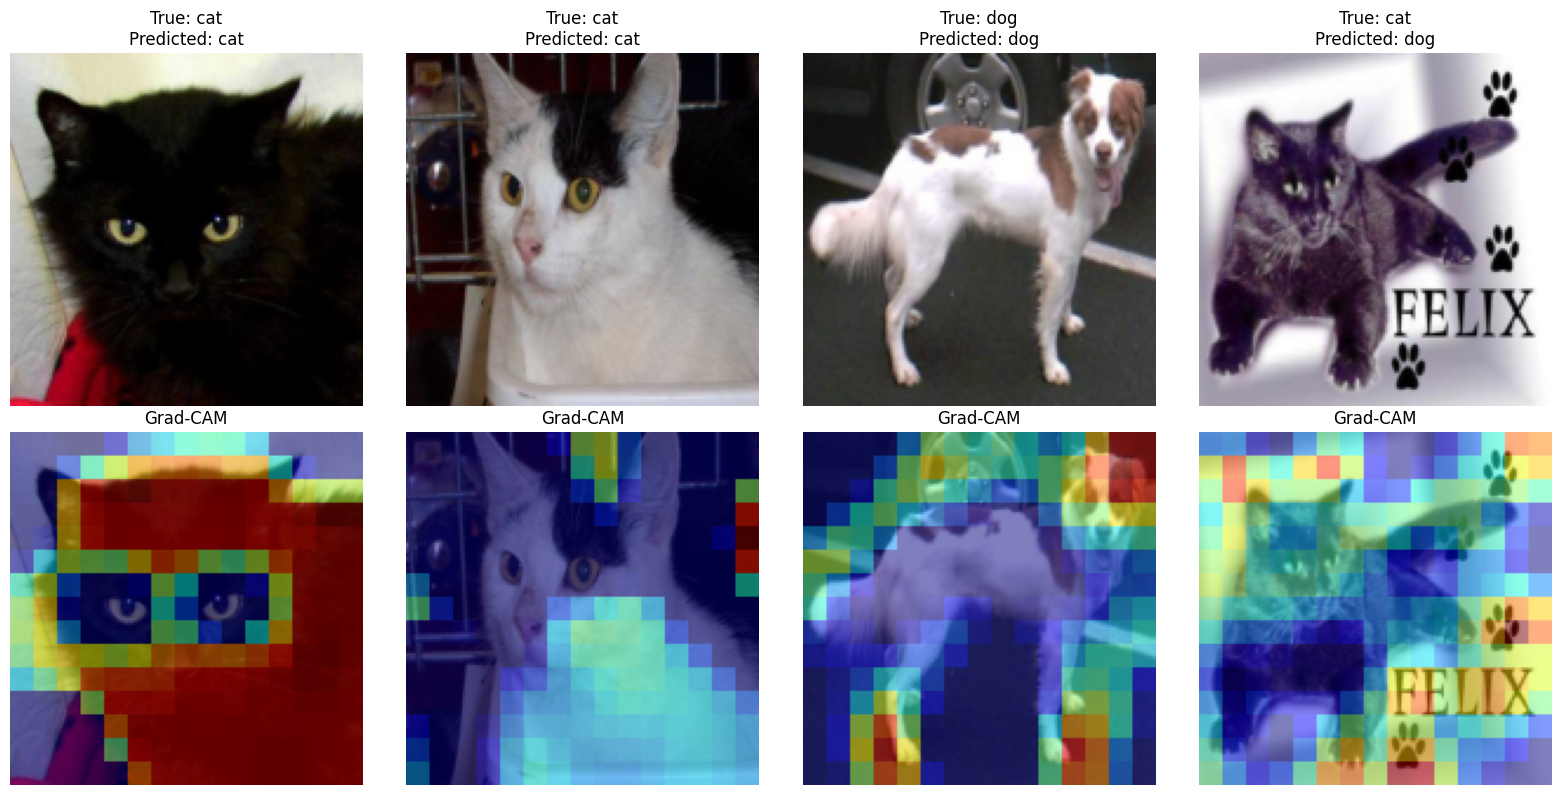

In [13]:
# Final convolutional layer of the model
target_layer = model.features[9]

gradcam = LayerGradCam(predicted_class_score, target_layer)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, example in enumerate(selected_examples):
    image = example["image"].unsqueeze(0).to(device)

    # Compute Grad-CAM for the model's predicted class
    attribution = gradcam.attribute(image)

    # Resize the coarse Grad-CAM map to the input image size
    attribution = LayerAttribution.interpolate(
        attribution,
        (150, 150)
    )

    heatmap = attribution.squeeze().detach().cpu().numpy()

    # Keep positive importance and normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Undo normalization for displaying the original image
    display_image = example["image"] * 0.5 + 0.5
    display_image = display_image.permute(1, 2, 0).numpy()

    true_name = "dog" if example["true_label"] == 1 else "cat"
    pred_name = "dog" if example["predicted_label"] == 1 else "cat"

    axes[0, i].imshow(display_image)
    axes[0, i].set_title(
        f"True: {true_name}\nPredicted: {pred_name}"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(display_image)
    axes[1, i].imshow(
        heatmap,
        cmap="jet",
        alpha=0.5
    )
    axes[1, i].set_title("Grad-CAM")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### Grad-CAM observations

1. **Correct cat 1:** The strongest activation is around the cat and its head.
2. **Correct cat 2:** Attention is spread across the cat and nearby regions.
3. **Correct dog:** The model uses regions around the dog's body as well as some background.
4. **Misclassified cat:** Strong activation appears around the cat but also around the text and graphics in the image.

## Comparison

Integrated Gradients gives a more detailed pixel-level explanation, while Grad-CAM shows broader regions of importance. Both methods generally focus on the animals in the correctly classified images. In the misclassified cat image, however, both methods also highlight the "FELIX" text and surrounding graphics. This suggests the model may have learned to use some background or contextual features in addition to features of the animals themselves, which can contribute to incorrect predictions.